# Retail Sales Analysis using Python (Pandas)

## Project Overview

This project performs exploratory data analysis (EDA) on a retail sales dataset using Python and pandas. The objective is to evaluate business performance, identify profitable product categories, analyze customer purchasing behavior, examine geographical profitability, and uncover seasonal sales trends to support data-driven business decisions.

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

### Dataset

- Source: Superstore Retail Sales Dataset
- Rows: 9,994
- Columns: 21

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
retail_df = pd.read_csv(
    "../01_Data/Retail Sales Dataset.csv",
    encoding="cp1252"
)

In [3]:
retail_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
retail_df.shape

(9994, 21)

In [5]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
retail_df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
retail_df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
retail_df.duplicated().sum()

np.int64(0)

In [9]:
retail_df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

## Data Cleaning

The dataset contained no missing values or duplicate rows. However, the **Order Date** column contained mixed date formats (`DD-MM-YYYY`, `M/DD/YYYY`, and `MM/DD/YYYY`). A custom function was used to standardize all dates into pandas datetime format before performing time-based analysis.

In [10]:
def convert_date(date):

    if "-" in date:
        return pd.to_datetime(date, format="%d-%m-%Y")

    else:
        return pd.to_datetime(date, format="%m/%d/%Y")


In [11]:
retail_df["Order Date"] = retail_df["Order Date"].apply(convert_date)

In [12]:
retail_df["Year"] = retail_df["Order Date"].dt.year
retail_df["Month"] = retail_df["Order Date"].dt.month

In [13]:
retail_df[["Order Date", "Year", "Month"]].head()

,Order Date,Year,Month
0,2016-08-11,2016,8
1,2016-08-11,2016,8
2,2016-12-06,2016,12
3,2015-11-10,2015,11
4,2015-11-10,2015,11


## Business Question 1: Overall Business Performance
### Objective
Summarize the overall business performance by calculating:
- Total Sales
- Total Profit
- Number of Distinct Orders

In [14]:
total_sales = retail_df["Sales"].sum()
total_profit = retail_df["Profit"].sum()
distinct_orders = retail_df["Order ID"].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Distinct Orders:", distinct_orders)

Total Sales: 2297200.8603
Total Profit: 286397.0217
Distinct Orders: 5009


## Business Question 2: Sales and Profit Analysis by Category
### Objective
Analyze the total sales and profit generated by each product category to identify the highest-performing category.

In [15]:
category_summary = (
    retail_df
        .groupby("Category")[["Sales", "Profit"]]
        .sum()
        .sort_values("Sales", ascending=False)
)

category_summary

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


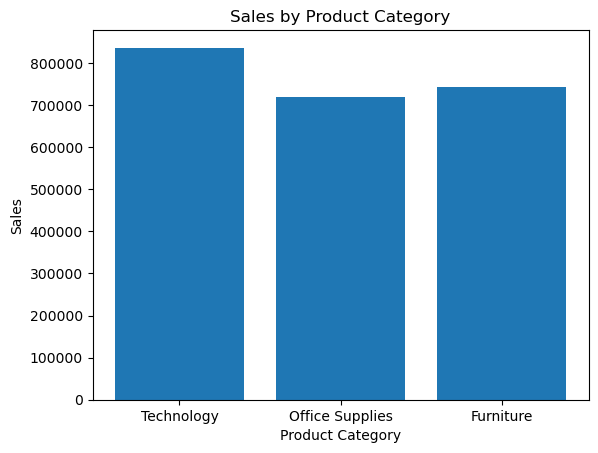

In [86]:
x = category_summary.index
y = category_summary["Sales"]

plt.bar(x, y)
plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales")
plt.show()

### Business Insight
- Technology generated the highest sales and the highest profit among all product categories.
- Furniture achieved strong sales but substantially lower profit than Technology and Office Supplies.
- High sales do not necessarily translate into high profitability, highlighting the importance of evaluating both revenue and profit.

## Business Question 3: Profit Margin by Product Category
### Objective
Analyze the profit margin of each product category to evaluate how efficiently each category converts sales into profit.


In [16]:
category_summary["Profit_Margin"]=(category_summary["Profit"]/category_summary["Sales"])*100
category_summary = category_summary.sort_values(
    "Profit_Margin",
    ascending=False
)
category_summary

,Sales,Profit,Profit_Margin
Category,,,
Technology,836154.0330,145454.9481,17.395712
Office Supplies,719047.0320,122490.8008,17.035158
Furniture,741999.7953,18451.2728,2.486695


### Business Insight
- Technology achieved the highest profit margin of approximately 17%.
- Furniture recorded the lowest profit margin despite having sales comparable to Office Supplies.
- Profit margin provides a better measure of business efficiency than sales alone.

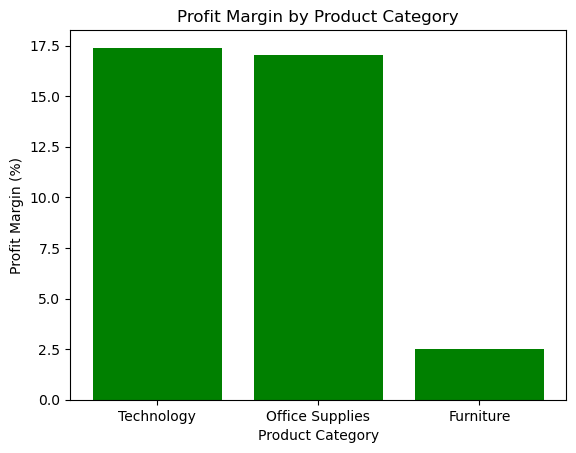

In [57]:
x = category_summary.index
y = category_summary["Profit_Margin"] 
plt.bar(x, y, color='green')
plt.title("Profit Margin by Product Category") 
plt.xlabel("Product Category")
plt.ylabel("Profit Margin (%)") 
plt.show()

## Business Question 4: Profit and Sales Analysis by Product Sub-Category
### Objective
Analyze the total sales, total profit and profit margin of each product sub-category to evaluate how efficiently each sub-category converts sales into profit.

In [44]:
sub_category_summary = (
    retail_df
        .groupby("Sub-Category")[["Sales", "Profit"]]
        .sum()
)
sub_category_summary["Profit_Margin"] = (sub_category_summary["Profit"]/sub_category_summary["Sales"])*100
sub_category_summary["No_of_Order_Lines"] = retail_df.groupby("Sub-Category")["Sales"].count()
sub_category_summary= sub_category_summary.sort_values("Profit_Margin", ascending=False)
sub_category_summary

,Sales,Profit,Profit_Margin,No_of_Order_Lines
Sub-Category,,,,
Labels,12486.3120,5546.2540,44.418672,364
Paper,78479.2060,34053.5693,43.391837,1370
Envelopes,16476.4020,6964.1767,42.267582,254
Copiers,149528.0300,55617.8249,37.195585,68
Fasteners,3024.2800,949.5182,31.396504,217
Accessories,167380.3180,41936.6357,25.054700,775
Art,27118.7920,6527.7870,24.071083,796
Appliances,107532.1610,18138.0054,16.867517,466
Binders,203412.7330,30221.7633,14.857361,1523


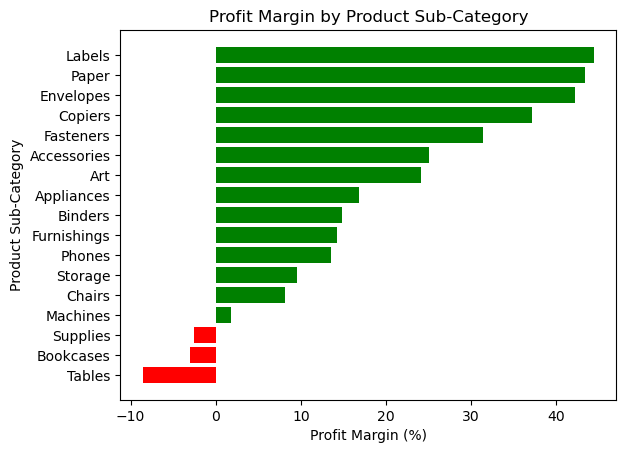

In [83]:
plot_data = sub_category_summary.sort_values("Profit_Margin")
x = plot_data.index
y = plot_data["Profit_Margin"]
colors = []

for margin in plot_data["Profit_Margin"]:
    if margin >= 0:
        colors.append("green")
    else:
        colors.append("red")
plt.barh(x, y, color=colors)
plt.title("Profit Margin by Product Sub-Category")
plt.ylabel("Product Sub-Category")
plt.xlabel("Profit Margin (%)")
plt.show()

### Business Insight
- Labels and Paper achieved the highest profit margins of approximately 44% and 43%, respectively.
- Supplies, Bookcases and Tables recorded negative profit margins.
- Profitability varies significantly across sub-categories, indicating that high sales volume alone does not guarantee high profit.

## Business Question 5: Identifying High-Value Customers
### Objective
To analyze customer purchasing behaviour and identify high-value customers based on their sales, profitability, and purchasing frequency.

In [52]:
customer_summary = (
    retail_df
        .groupby("Customer Name")[["Sales", "Profit"]]
        .sum()
)
customer_summary["No_of_Orders"] = retail_df.groupby("Customer Name")["Order ID"].nunique()
customer_summary=customer_summary.sort_values("Profit", ascending=False)
top_10_customers = customer_summary.head(10)
top_10_customers

,Sales,Profit,No_of_Orders
Customer Name,,,
Tamara Chand,19052.218,8981.3239,5
Raymond Buch,15117.339,6976.0959,6
Sanjit Chand,14142.334,5757.4119,9
Hunter Lopez,12873.298,5622.4292,6
Adrian Barton,14473.571,5444.8055,10
Tom Ashbrook,14595.620,4703.7883,4
Christopher Martinez,8954.020,3899.8904,4
Keith Dawkins,8181.256,3038.6254,12
Andy Reiter,6608.448,2884.6208,6


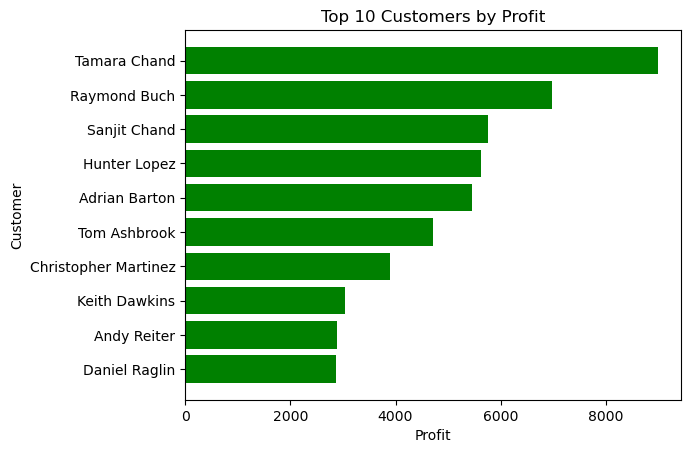

In [58]:
x =top_10_customers.index
y = top_10_customers["Profit"]
plt.barh(x, y, color="green")
plt.title("Top 10 Customers by Profit")
plt.ylabel("Customer")
plt.xlabel("Profit")
plt.gca().invert_yaxis()
plt.show()

### Business Insight
- Tamara Chand, Raymond Buch and Sanjit Chand generated the highest profits among all customers.
- High order volume does not necessarily translate into higher profitability.
- Identifying high-value customers can support targeted loyalty and retention strategies.

## Business Question 6: Geographical Profitability Analysis
### Objective
Analyze the profitability across different states and identify the states that require management attention due to negative profits.

In [19]:
state_summary = (
    retail_df
        .groupby("State")[["Sales", "Profit"]]
        .sum()
)
state_summary["No_of_Order_Lines"] = retail_df.groupby("State")["Sales"].count()
state_summary=state_summary[state_summary["Profit"]<0]
state_summary= state_summary.sort_values("Profit")
state_summary

,Sales,Profit,No_of_Order_Lines
State,,,
Texas,170188.0458,-25729.3563,985
Ohio,78258.1360,-16971.3766,469
Pennsylvania,116511.9140,-15559.9603,587
Illinois,80166.1010,-12607.8870,492
North Carolina,55603.1640,-7490.9122,249
Colorado,32108.1180,-6527.8579,182
Tennessee,30661.8730,-5341.6936,183
Arizona,35282.0010,-3427.9246,224
Florida,89473.7080,-3399.3017,383


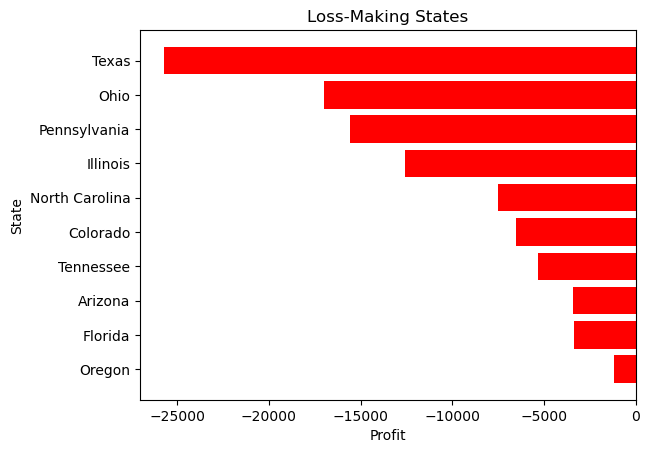

In [84]:
x =state_summary.index
y =state_summary["Profit"]
plt.barh(x, y, color="red")
plt.title("Loss-Making States")
plt.ylabel("State")
plt.xlabel("Profit")
plt.gca().invert_yaxis()
plt.show()

### Business Insight
- Texas recorded the highest loss, followed by Ohio and Pennsylvania.
- Several states generated strong sales but still resulted in negative overall profit.
- This indicates that high sales do not necessarily guarantee profitability across regions.

## Business Question 7:  Monthly Sales Trend Analysis
### Objective
Analyze the monthly sales trend to identify seasonal patterns and periods of high and low sales.

In [20]:
month_summary = (
    retail_df
        .groupby(["Year", "Month"])[["Sales","Profit"]]
        .sum()
)
month_summary["No_of_Order_Lines"] =  retail_df.groupby(["Year", "Month"])["Sales"].count()
month_summary


Sales      Profit  No_of_Order_Lines
Year Month                                           
2014 1      28953.7060   4549.4546                131
     2      12743.1080   2654.5569                 86
     3      54801.9060     92.6990                168
     4      24710.0160   4601.0714                121
     5      29639.8340   3912.2499                148
     6      29287.0306   4499.7446                137
     7      35341.2460  -1783.5425                156
     8      37854.5475   2081.2676                150
     9      66110.2238  10232.2626                239
     10     34561.9470   4075.1499                145
     11     64817.6185   6653.2762                263
     12     65426.3147   7975.7839                249
2015 1      29347.3864   1237.0630                 86
     2      20728.3520   2171.4036                102
     3      40876.6112   9165.6802                154
     4      38056.9685   6132.8819                159
     5      30933.7145   2779.3998                177
     6      28862.1982   4788.4461                152
     7      28730.3760    671.7960                132
     8      50094.5280  10112.2771                178
     9      66729.3290   9929.3009                278
     10     32025.0750   3433.2405                155
     11     50732.3090   5582.4023                282
     12     53415.6612   5614.7123                247
2016 1      38048.1840   8501.1690                154
     2      49238.4100  14683.7152                126
     3      49612.0450   1950.3496                193
     4      45192.2780   7423.2803                188
     5      64964.3218   9975.3694                260
     6      38991.9430   4480.3350                189
     7      42773.3950   6122.4545                208
     8      46339.9884    859.4491                237
     9      41985.1423   5171.8973                236
     10     52268.1500   8256.4675                236
     11     66837.5850   3057.5166                293
     12     72954.1555  11313.1708                267
2017 1      64734.3110  10879.4151                226
     2      50011.4894   4243.9720                234
     3      74774.0838  18127.8605                304
     4      39072.0016  -5890.0374                229
     5      40882.4464   7567.3914                241
     6      47742.3255   7396.3759                229
     7      54382.0875   4997.9408                244
     8      75675.3040  11767.3512                251
     9      74164.6080   9221.4166                385
     10     65501.1622   6572.0675                272
     11     89306.2400  11141.8845                375
     12     56969.1958   7413.6315                322

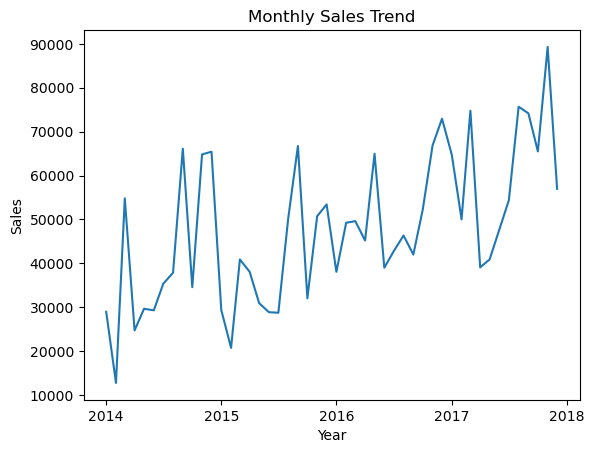

In [74]:
plot_data = month_summary.reset_index()
plot_data["Date"] = pd.to_datetime(
    plot_data[["Year", "Month"]].assign(Day=1)
)
x = plot_data["Date"]
y =plot_data["Sales"]
plt.plot(x, y)
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xlabel("Year")
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()

### Business Insight
- Sales generally increased from 2014 to 2017, with noticeable peaks during the later months of each year.
- Monthly sales exhibit seasonal fluctuations, indicating periods of higher and lower customer demand.
- Time-based sales analysis can support inventory planning and promotional strategies.

## Business Question 8: Impact of Discounts on Profitability
### Objective
Analyze the relationship between discounts and profitability across product sub-categories.

In [47]:
sub_category_summary["Average_Discount"] = (
    retail_df.groupby("Sub-Category")["Discount"].mean()
)
sub_category_summary = sub_category_summary[
    [
        "Average_Discount",
        "Sales",
        "Profit",
        "Profit_Margin",
        "No_of_Order_Lines",
    ]
]
sub_category_summary = sub_category_summary.sort_values(
    "Average_Discount",
    ascending=False
)

sub_category_summary


,Average_Discount,Sales,Profit,Profit_Margin,No_of_Order_Lines
Sub-Category,,,,,
Binders,0.372292,203412.7330,30221.7633,14.857361,1523
Machines,0.306087,189238.6310,3384.7569,1.788618,115
Tables,0.261285,206965.5320,-17725.4811,-8.564460,319
Bookcases,0.211140,114879.9963,-3472.5560,-3.022768,228
Chairs,0.170178,328449.1030,26590.1663,8.095673,617
Appliances,0.166524,107532.1610,18138.0054,16.867517,466
Copiers,0.161765,149528.0300,55617.8249,37.195585,68
Phones,0.154556,330007.0540,44515.7306,13.489327,889
Furnishings,0.138349,91705.1640,13059.1436,14.240358,957


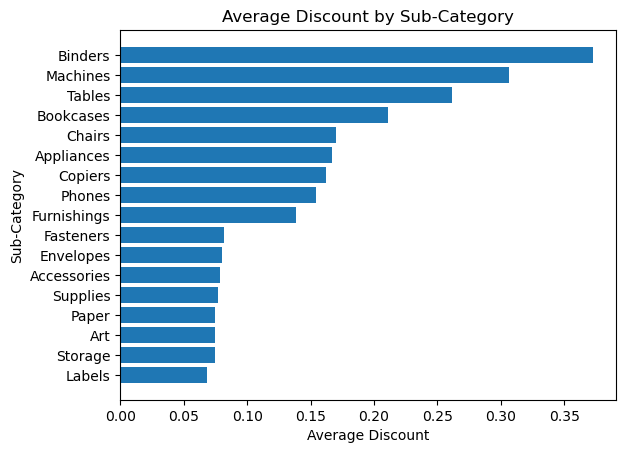

In [77]:
x =sub_category_summary.index
y = sub_category_summary["Average_Discount"]
plt.barh(x, y)
plt.title("Average Discount by Sub-Category")
plt.ylabel("Sub-Category")
plt.xlabel("Average Discount")
plt.gca().invert_yaxis()
plt.show()

### Business Insight
- Binders received the highest average discount while maintaining a positive profit margin.
- Tables and Bookcases also received relatively high average discounts but generated negative profit margins.
- Higher discounts do not necessarily result in lower profitability, indicating that discount is only one of several factors influencing profit.